# 05 Decision Tree Pruning Analysis

This notebook studies cost-complexity pruning for the Decision Tree. It uses only training and validation data. The final test set is not loaded or used.

## What Is Pruning?

Pruning removes parts of a Decision Tree that add complexity without clearly improving generalization. It can reduce overfitting by making the tree simpler and less likely to memorize small training-data patterns.

`ccp_alpha` controls cost-complexity pruning. A larger value penalizes tree complexity more strongly, usually producing fewer leaves and a shallower tree.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

from src.analyze_pruning import (
    PRUNING_COMPLEXITY_FIGURE,
    PRUNING_F1_FIGURE,
    analyze_pruning,
    save_pruning_figures,
)

## Run the Pruning Experiment

The script first gets possible `ccp_alpha` values from `cost_complexity_pruning_path()`, then tests a representative subset so the experiment remains manageable.

In [2]:
pruning_results = analyze_pruning()
save_pruning_figures(pruning_results)
pruning_results.round(6)

,ccp_alpha,training_accuracy,validation_accuracy,training_f1_phishing,validation_f1_phishing,tree_depth,leaves
0,0.000000,0.995874,0.995307,0.995161,0.994495,10,72
1,0.000008,0.995874,0.995307,0.995161,0.994495,10,70
2,0.000011,0.995874,0.995307,0.995161,0.994495,10,67
3,0.000013,0.995868,0.995307,0.995153,0.994495,10,65
4,0.000014,0.995868,0.995307,0.995153,0.994495,10,61
5,0.000016,0.995856,0.995307,0.995139,0.994495,10,58
6,0.000016,0.995850,0.995307,0.995132,0.994495,10,56
7,0.000020,0.995838,0.995307,0.995118,0.994495,10,53
8,0.000024,0.995814,0.995307,0.995090,0.994495,10,50
9,0.000025,0.995814,0.995307,0.995090,0.994495,10,47


The table compares training and validation performance for each tested alpha. We should not choose a model only because it has the highest training score; validation performance and model simplicity both matter.

## Pruning Versus Phishing F1-Score

This plot shows how phishing F1-score changes as pruning becomes stronger.

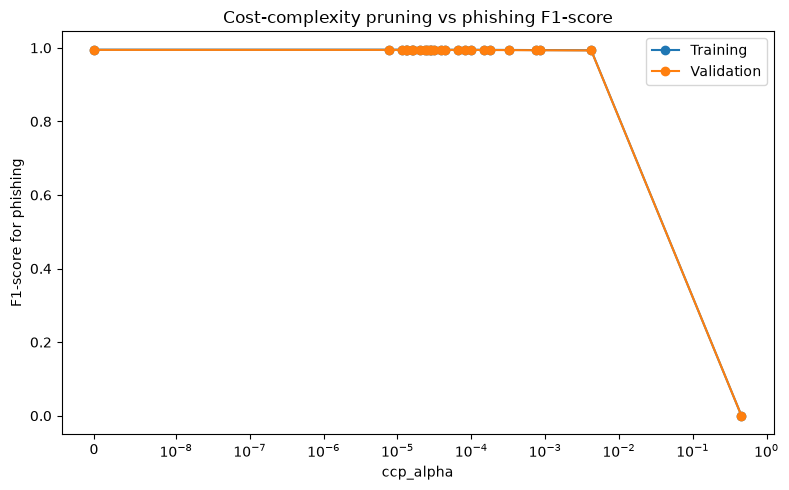

WindowsPath('D:/Projects/phishing-url-detection/reports/figures/pruning_f1.png')

In [3]:
plt.figure(figsize=(8, 5))
plt.plot(pruning_results["ccp_alpha"], pruning_results["training_f1_phishing"], marker="o", label="Training")
plt.plot(pruning_results["ccp_alpha"], pruning_results["validation_f1_phishing"], marker="o", label="Validation")
plt.title("Cost-complexity pruning vs phishing F1-score")
plt.xlabel("ccp_alpha")
plt.ylabel("F1-score for phishing")
plt.xscale("symlog", linthresh=1e-8)
plt.legend()
plt.tight_layout()
plt.show()

PRUNING_F1_FIGURE

Small alpha values keep validation phishing F1 close to the unpruned tuned tree. Very large alpha values prune too aggressively and underfit.

## Pruning Versus Tree Complexity

This plot shows how pruning changes depth and number of leaves.

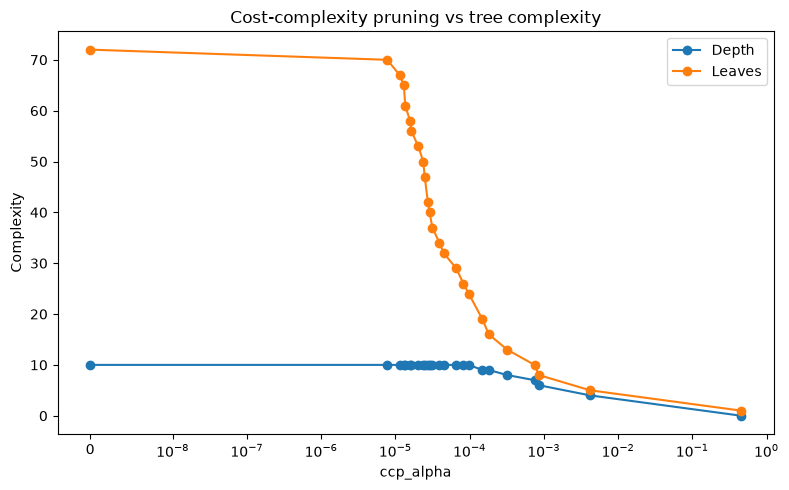

WindowsPath('D:/Projects/phishing-url-detection/reports/figures/pruning_complexity.png')

In [4]:
plt.figure(figsize=(8, 5))
plt.plot(pruning_results["ccp_alpha"], pruning_results["tree_depth"], marker="o", label="Depth")
plt.plot(pruning_results["ccp_alpha"], pruning_results["leaves"], marker="o", label="Leaves")
plt.title("Cost-complexity pruning vs tree complexity")
plt.xlabel("ccp_alpha")
plt.ylabel("Complexity")
plt.xscale("symlog", linthresh=1e-8)
plt.legend()
plt.tight_layout()
plt.show()

PRUNING_COMPLEXITY_FIGURE

The useful tradeoff is a tree that remains accurate on validation data while using fewer leaves. In this run, light pruning reduces leaves but does not improve validation phishing F1 over the unpruned tuned tree.